In [ ]:
%load_ext autoreload
%autoreload 2

from spatial_tcr.utils import setup_plotting, switch_cwd_to_root

switch_cwd_to_root()

figure_dir = "figures/revision-figures"
setup_plotting(figure_dir, display_dpi=300, save_dpi=300)


import pandas as pd
import scanpy as sc

from spatial_tcr.clonal_expansion import find_avbv_clones, find_gvdv_clones
from spatial_tcr.plotting import (
    plot_side_by_side_counts,
)
from spatial_tcr.tcr import get_tcr_genes

Changed working directory to /bonn-epyc/projects/dschaub/analysis-projects/spatial-tcr
Arial font found!


## Load data

In [2]:
data_dir = "data/xenium/processed"
path = f"{data_dir}/08.1-kidney_tcr_clonal_clusters.h5ad"
adata = sc.read_h5ad(path)

# remove control samples
adata = adata[adata.obs["condition"] == "ANCA"].copy()
adata

AnnData object with n_obs × n_vars = 389390 × 431
    obs: 'sample', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'condition', 'cc', 'cell_type_no_tcr', 'cell_type_no_tcr_prob', 'tcell_subtype', 'cell_type_l1', 'cell_type_l2', 'is_ATL', 'is_B', 'is_CNT', 'is_DCT', 'is_DTL', 'is_EC', 'is_FIB', 'is_IC', 'is_MAST', 'is_MC', 'is_MDC', 'is_Mac', 'is_N', 'is_NEU', 'is_PC', 'is_PEC', 'is_PL', 'is_POD', 'is_PT', 'is_PapE', 'is_T', 'is_TAL', 'is_VSM/P', 'is_cDC', 'is_cycMNP', 'is_glom. EC', 'is_pDC', 'is_unknown', 'leiden', 'glom_annot', 'in_glom', 'tcell_density_group', 'tcell_density', 'tcell_infiltrate', 'cell_type_l1.1', 'av_

In [3]:
av_genes, bv_genes, dv_genes, gv_genes, tv_genes = get_tcr_genes(adata)

Found 35 TRAV genes, 31 TRBV genes, 3 TRDV genes, 14 TRGV genes


## Consider TRVs in all cells (not just T cells)

In [4]:
find_avbv_clones(adata, av_genes, bv_genes, layer="counts")

Found 49357 singlets
Found 9261 multiplets
Found 1348 valid multiplets
Found 61361 singlets
Found 11825 multiplets
Found 1404 valid multiplets
Found 13219 avbv clones


In [5]:
find_gvdv_clones(adata, gv_genes, dv_genes, layer="counts")

Found 27597 singlets
Found 3028 multiplets
Found 206 valid multiplets
Found 5412 singlets
Found 53 multiplets
Found 9 valid multiplets
Found 647 gvdv clones


In [6]:
adata.obs.head()

,sample,x_centroid,y_centroid,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,...,tcell_infiltrate,cell_type_l1.1,av_clone,bv_clone,avbv_clone,avbv_cluster,avbv_cluster_filtered,gv_clone,dv_clone,gvdv_clone
aaaafjcl-1output-XETG00088__0029040__Region_4__20240719__095642,XETG00088__0029040__Region_4__20240719__095642,827.634888,509.198273,53,0,0,0,0,53.0,43.846720,...,infiltrate,CD4+,TRAV12,None,NaN,NaN,NaN,None,None,NaN
aaaaifkm-1output-XETG00088__0029040__Region_4__20240719__095642,XETG00088__0029040__Region_4__20240719__095642,830.986328,526.856567,82,0,0,0,0,82.0,45.652970,...,infiltrate,FIB,None,None,NaN,NaN,NaN,TRGV3,None,NaN
aaabfnjj-1output-XETG00088__0029040__Region_4__20240719__095642,XETG00088__0029040__Region_4__20240719__095642,830.348694,516.403687,75,0,0,0,0,75.0,44.659533,...,infiltrate,CD8+,TRAV27,None,NaN,NaN,NaN,None,None,NaN
aaacfpcn-1output-XETG00088__0029040__Region_4__20240719__095642,XETG00088__0029040__Region_4__20240719__095642,835.537781,513.943237,55,0,0,0,0,55.0,37.660314,...,infiltrate,FIB,None,None,NaN,NaN,NaN,None,None,NaN
aaadlcmd-1output-XETG00088__0029040__Region_4__20240719__095642,XETG00088__0029040__Region_4__20240719__095642,834.702820,568.381409,83,0,0,0,0,83.0,54.729377,...,infiltrate,IC,None,None,NaN,NaN,NaN,None,None,NaN


## Consider TRVs in only T cells

In [7]:
ad_t = adata[adata.obs["cell_type_l1"] == "T"].copy()

(35, 1) (35, 1)


<Axes: title={'center': 'TRAV Detection Distribution in Single vs Paired Cells'}, ylabel='Fraction of cells'>

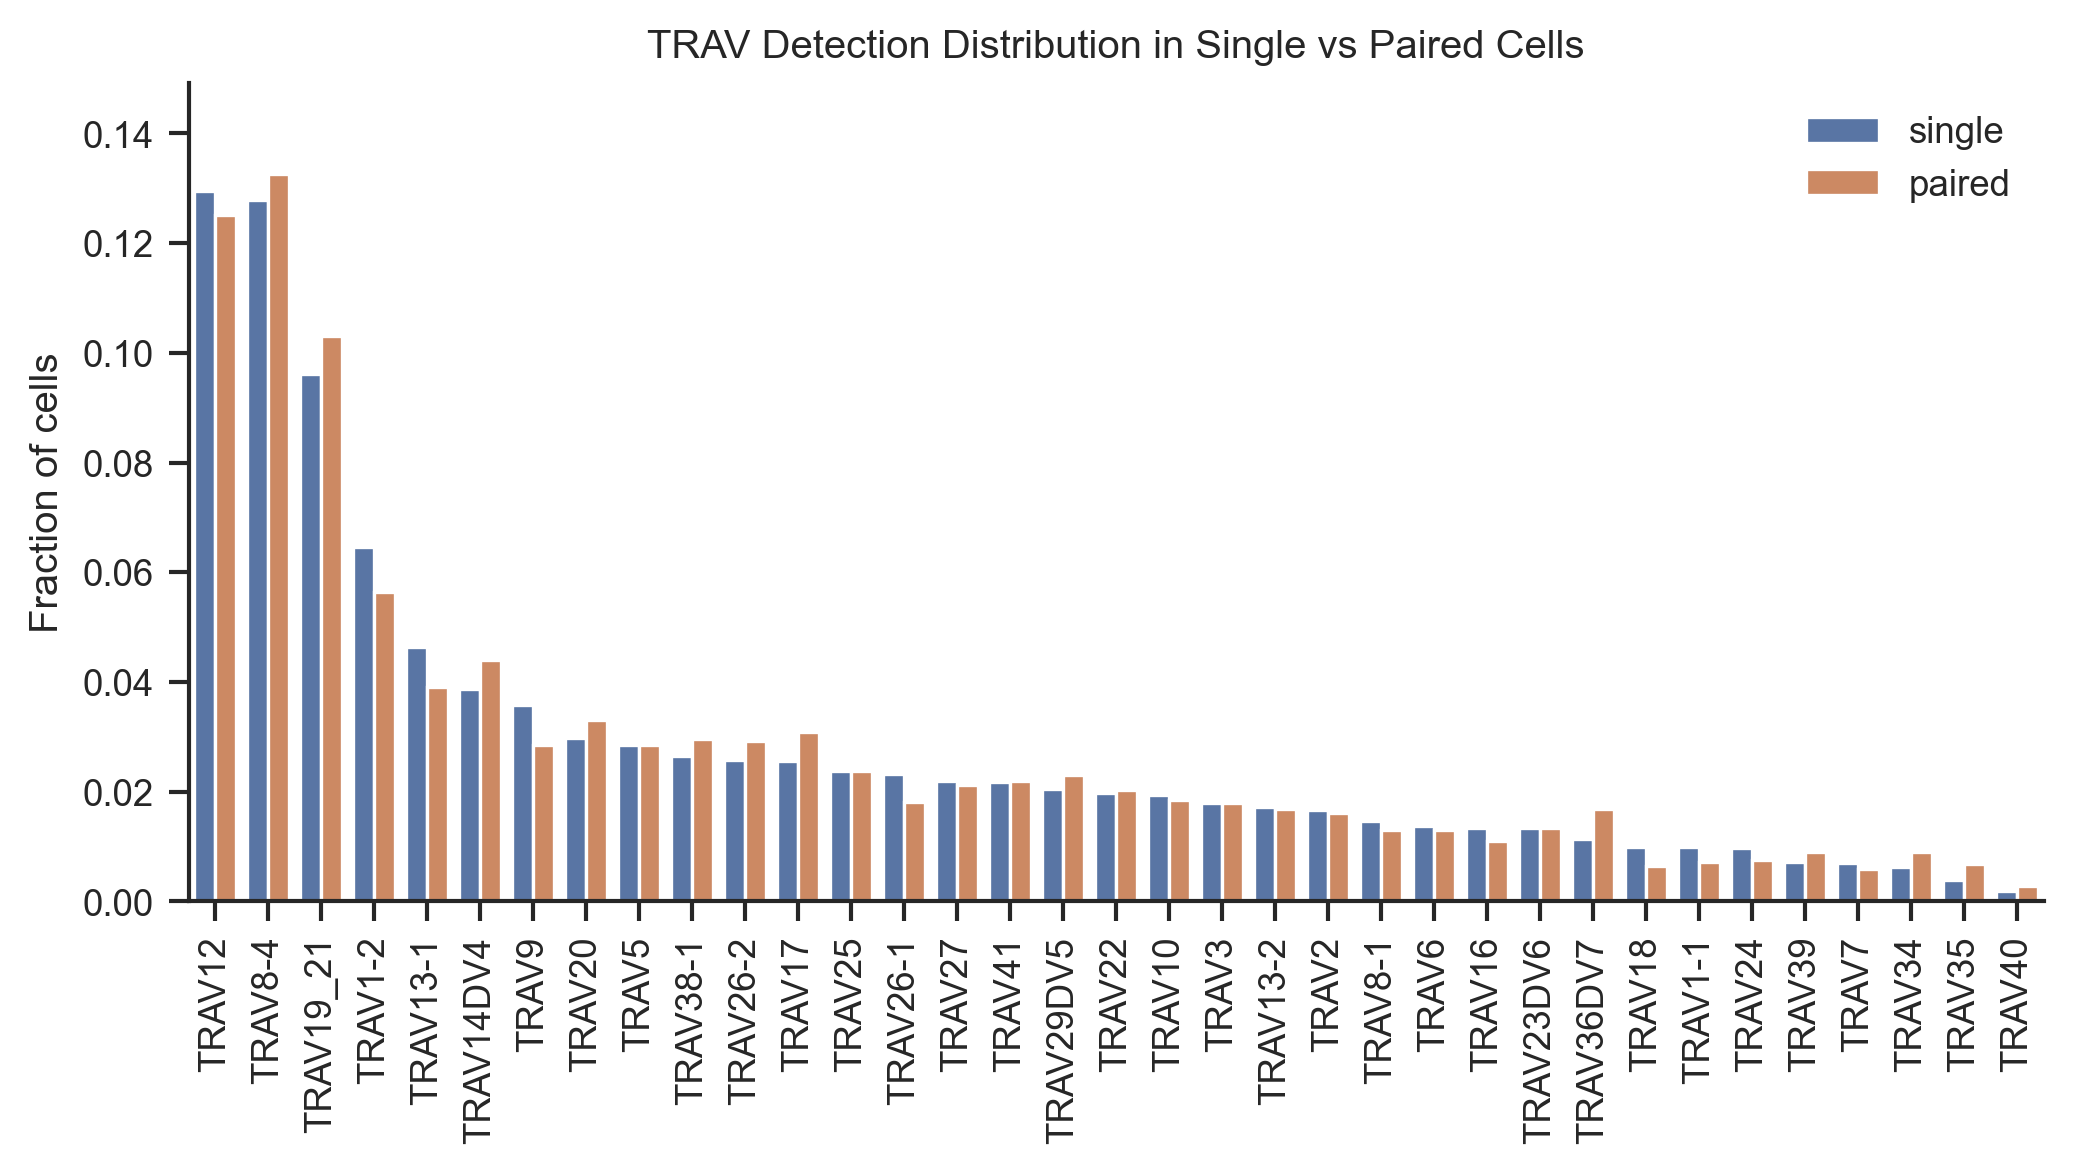

In [8]:
df_1 = ad_t.obs.loc[ad_t.obs["avbv_clone"].isna(), "av_clone"].value_counts().to_frame()
df_2 = (
    ad_t.obs.loc[~ad_t.obs["avbv_clone"].isna(), "av_clone"].value_counts().to_frame()
)
print(df_1.shape, df_2.shape)
av_counts = pd.concat([df_1, df_2], axis=1).fillna(0)
av_counts.columns = ["single", "paired"]

plot_side_by_side_counts(
    av_counts,
    normalize=True,
    title="TRAV Detection Distribution in Single vs Paired Cells",
    annotate_per_category=False,
    figsize=(7, 4),
    ylabel="Fraction of cells",
)

(31, 1) (31, 1)


<Axes: title={'center': 'TRBV Detection Distribution in Single vs Paired Cells'}, ylabel='Fraction of cells'>

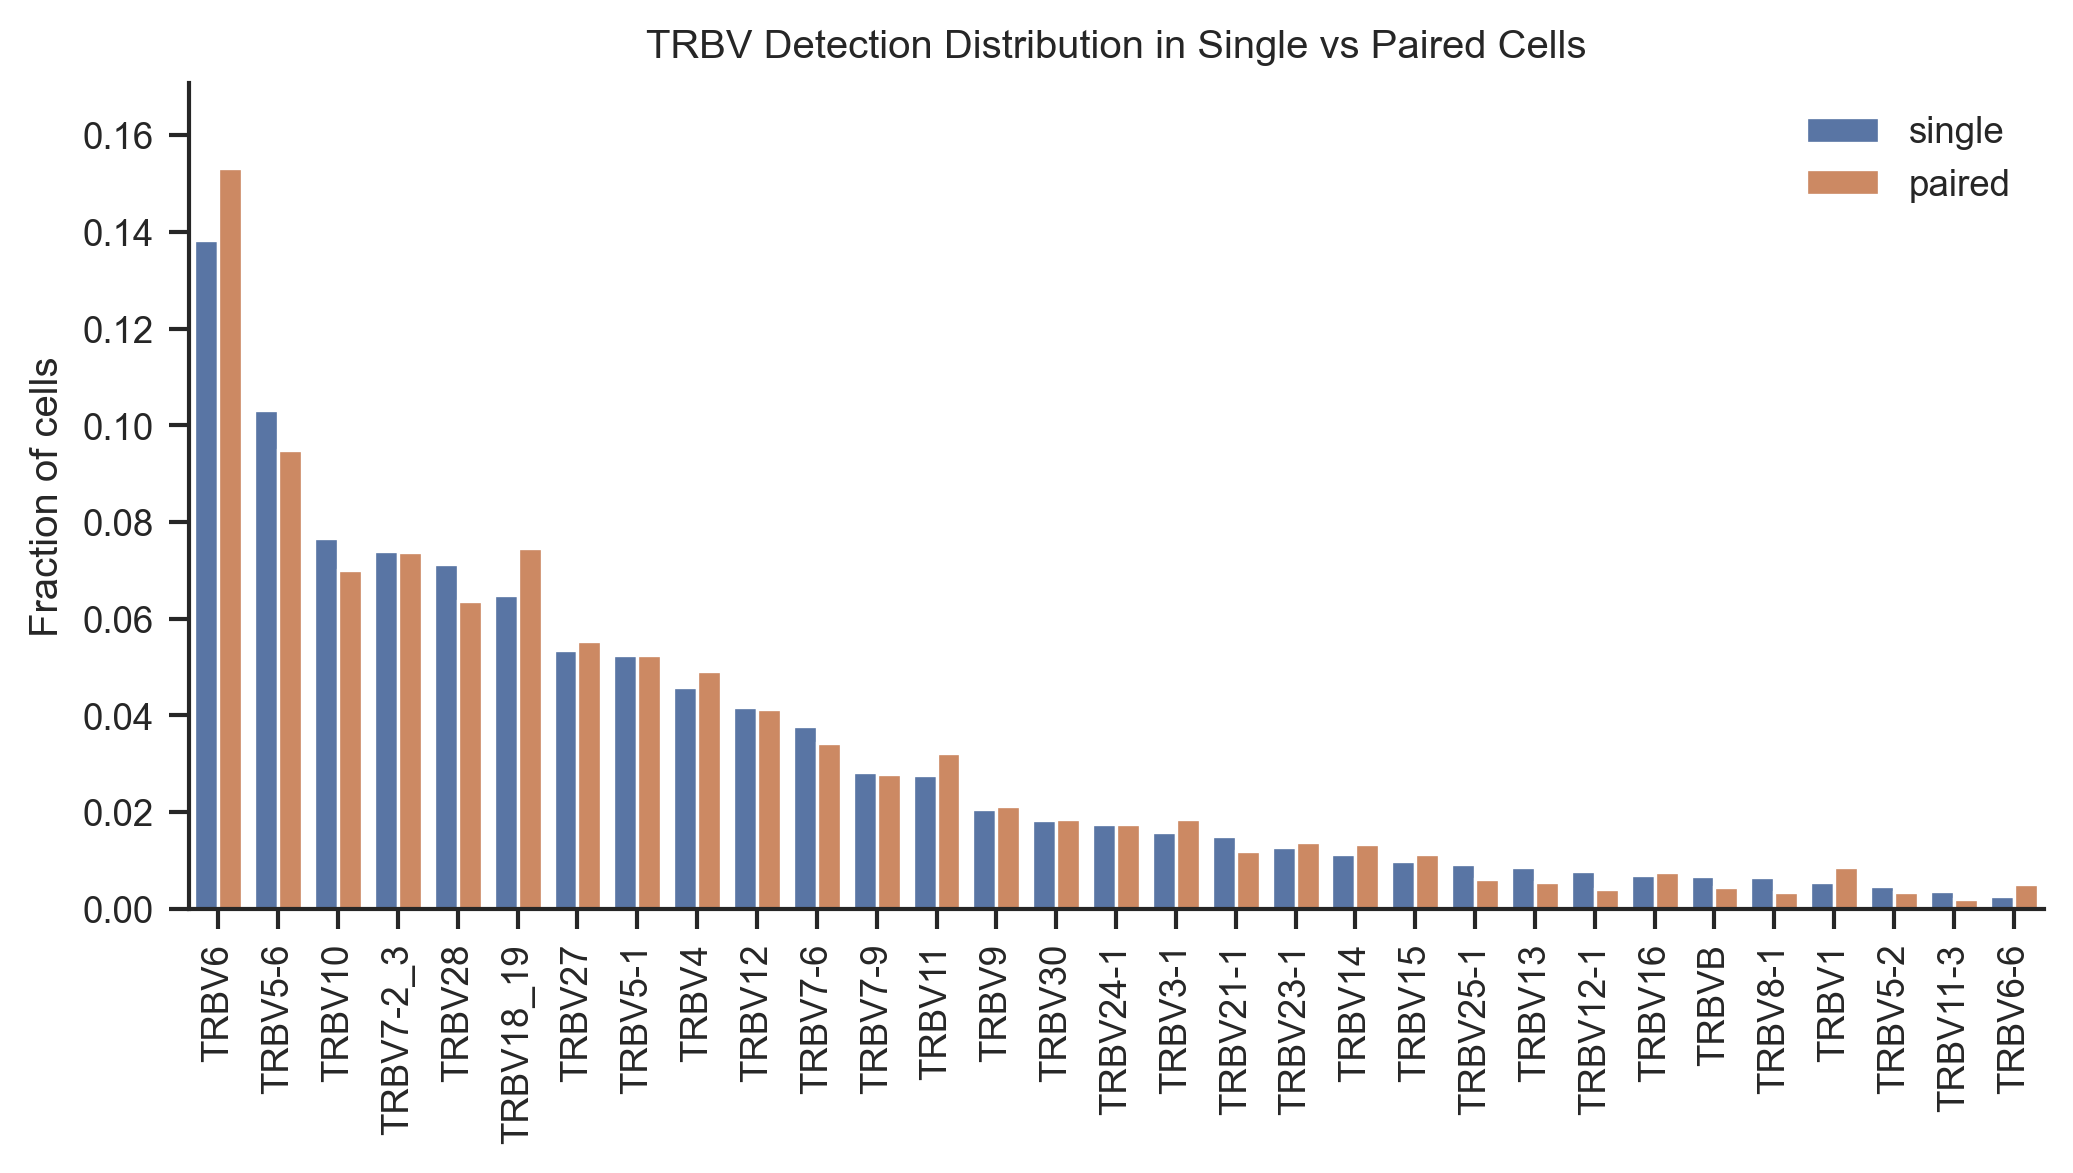

In [9]:
df_1 = ad_t.obs.loc[ad_t.obs["avbv_clone"].isna(), "bv_clone"].value_counts().to_frame()
df_2 = (
    ad_t.obs.loc[~ad_t.obs["avbv_clone"].isna(), "bv_clone"].value_counts().to_frame()
)
print(df_1.shape, df_2.shape)
bv_counts = pd.concat([df_1, df_2], axis=1).fillna(0)
bv_counts.columns = ["single", "paired"]

plot_side_by_side_counts(
    bv_counts,
    normalize=True,
    title="TRBV Detection Distribution in Single vs Paired Cells",
    annotate_per_category=False,
    figsize=(7, 4),
    ylabel="Fraction of cells",
)

(14, 1) (13, 1)


single    3444.0
paired     153.0
dtype: float64

np.int64(3597)

<Axes: title={'center': 'TRGV Detection Distribution in Single vs Paired Cells'}, ylabel='Fraction of cells'>

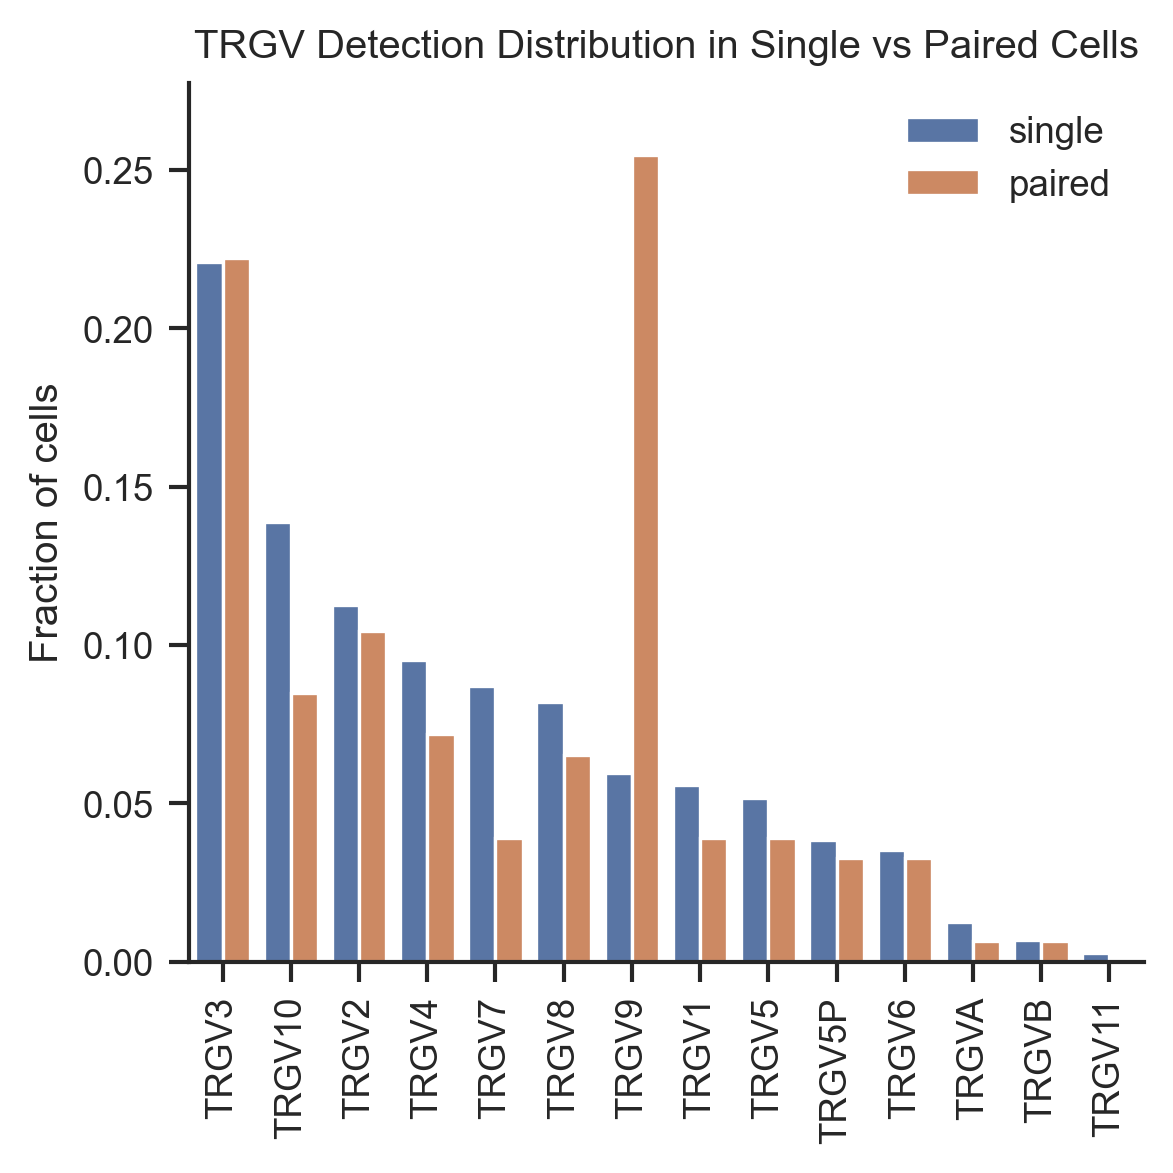

In [15]:
df_1 = ad_t.obs.loc[ad_t.obs["gvdv_clone"].isna(), "gv_clone"].value_counts().to_frame()
df_2 = (
    ad_t.obs.loc[~ad_t.obs["gvdv_clone"].isna(), "gv_clone"].value_counts().to_frame()
)
print(df_1.shape, df_2.shape)
gv_counts = pd.concat([df_1, df_2], axis=1).fillna(0)
gv_counts.columns = ["single", "paired"]

tot_counts = gv_counts.sum(axis=0)
display(tot_counts)
display(ad_t.obs["gv_clone"].value_counts().sum())

plot_side_by_side_counts(
    gv_counts,
    normalize=True,
    title="TRGV Detection Distribution in Single vs Paired Cells",
    annotate_per_category=False,
    figsize=(4, 4),
    ylabel="Fraction of cells",
)

(3, 1) (3, 1)


,single,paired
dv_clone,,
TRDV1,177,80
TRDV2,137,61
TRDV3,56,12


np.int64(523)

<Axes: title={'center': 'TRDV Detection Distribution in Single vs Paired Cells'}, ylabel='Fraction of cells'>

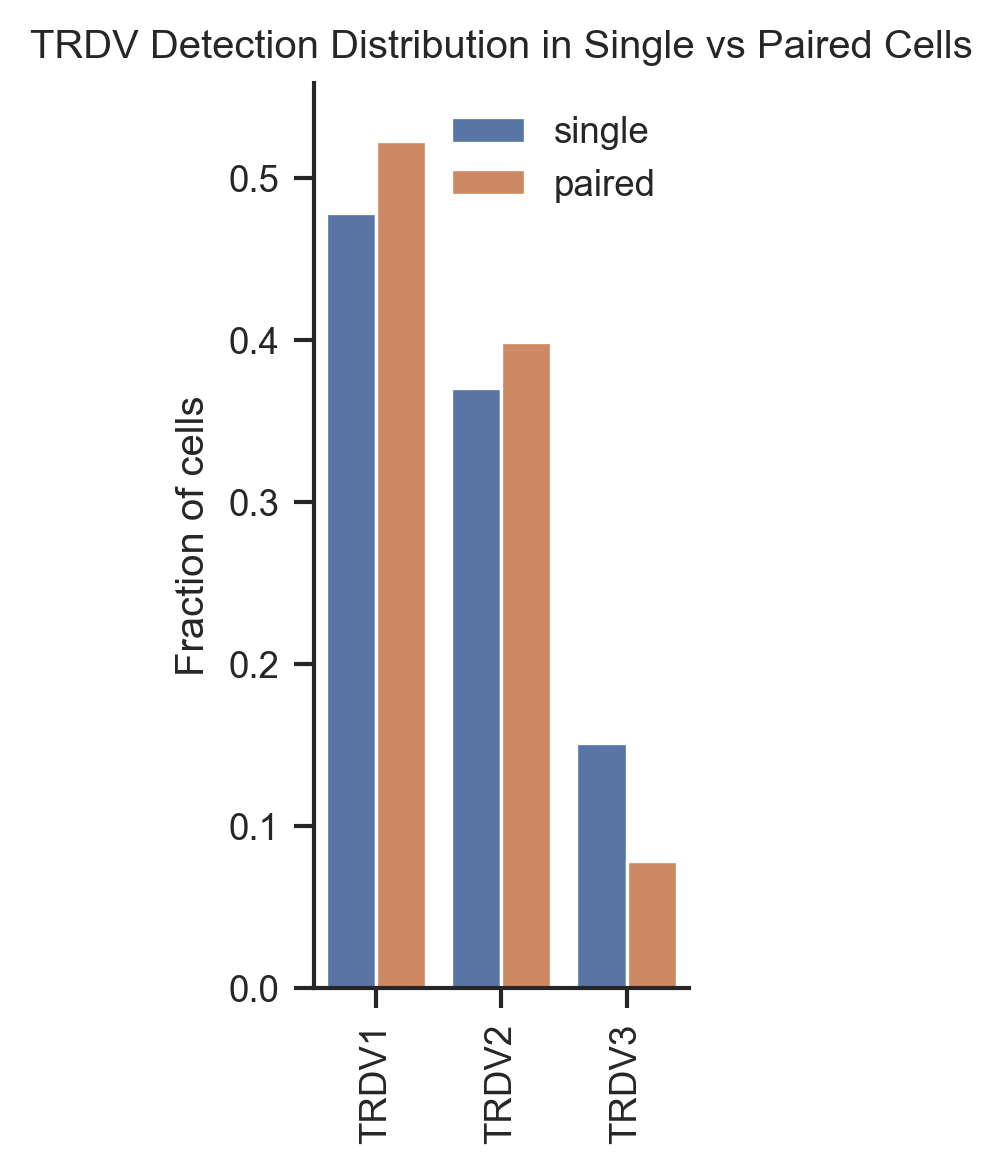

In [16]:
df_1 = ad_t.obs.loc[ad_t.obs["gvdv_clone"].isna(), "dv_clone"].value_counts().to_frame()
df_2 = (
    ad_t.obs.loc[~ad_t.obs["gvdv_clone"].isna(), "dv_clone"].value_counts().to_frame()
)
print(df_1.shape, df_2.shape)
dv_counts = pd.concat([df_1, df_2], axis=1).fillna(0)
dv_counts.columns = ["single", "paired"]

display(dv_counts)
display(ad_t.obs["dv_clone"].value_counts().sum())

plot_side_by_side_counts(
    dv_counts,
    normalize=True,
    title="TRDV Detection Distribution in Single vs Paired Cells",
    annotate_per_category=False,
    figsize=(2, 4),
    ylabel="Fraction of cells",
)

## TRVs in all cells

In [12]:
df_1 = adata.obs["av_clone"].value_counts().to_frame()
df_2 = (
    adata.obs.loc[~adata.obs["avbv_clone"].isna(), "av_clone"].value_counts().to_frame()
)
print(df_1.shape, df_2.shape)
av_counts = pd.concat([df_1, df_2], axis=1).fillna(0)
av_counts.columns = ["single", "paired"]
av_counts.head()

(35, 1) (35, 1)


,single,paired
av_clone,,
TRAV8-4,5733,1598
TRAV12,5144,1410
TRAV19_21,3428,983
TRAV1-2,2370,595
TRAV20,2150,543


<Axes: title={'center': 'Comparison of single '}, ylabel='Fraction'>

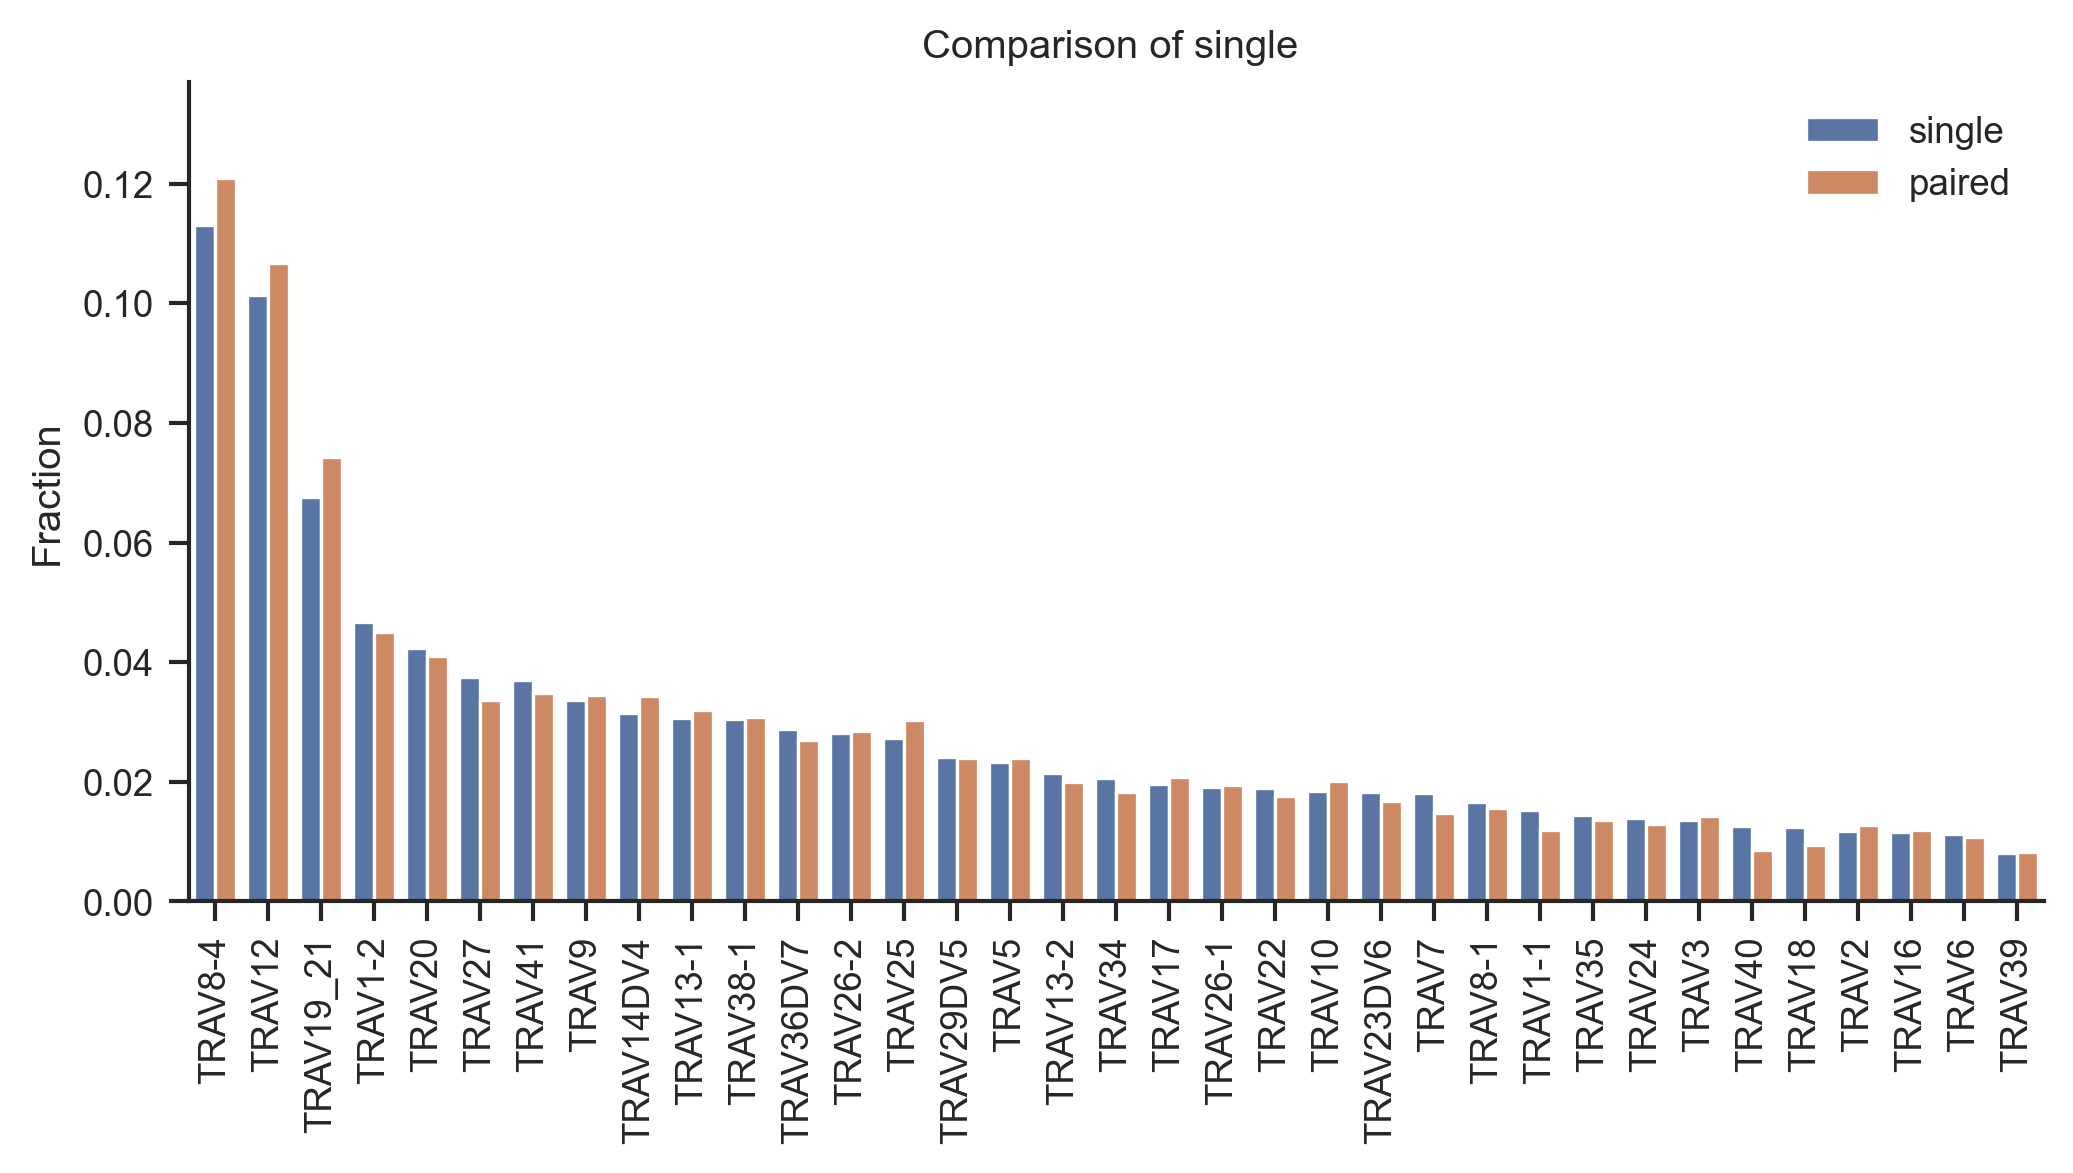

In [13]:
plot_side_by_side_counts(
    av_counts,
    normalize=True,
    title="Comparison of single ",
    annotate_per_category=False,
    figsize=(7, 4),
)

## Single vs paired for BV clones

In [14]:
df_1 = adata.obs["bv_clone"].value_counts().to_frame()
df_2 = (
    adata.obs.loc[~adata.obs["avbv_clone"].isna(), "bv_clone"].value_counts().to_frame()
)
print(df_1.shape, df_2.shape)
bv_counts = pd.concat([df_1, df_2], axis=1).fillna(0)
bv_counts.columns = ["single", "paired"]
bv_counts.head()

(31, 1) (31, 1)


,single,paired
bv_clone,,
TRBV5-6,11674,2119
TRBV6,8794,1951
TRBV10,4747,960
TRBV7-2_3,2681,677
TRBV7-6,2582,524


<Axes: title={'center': 'Single vs paired BV clone distribution'}, ylabel='Fraction'>

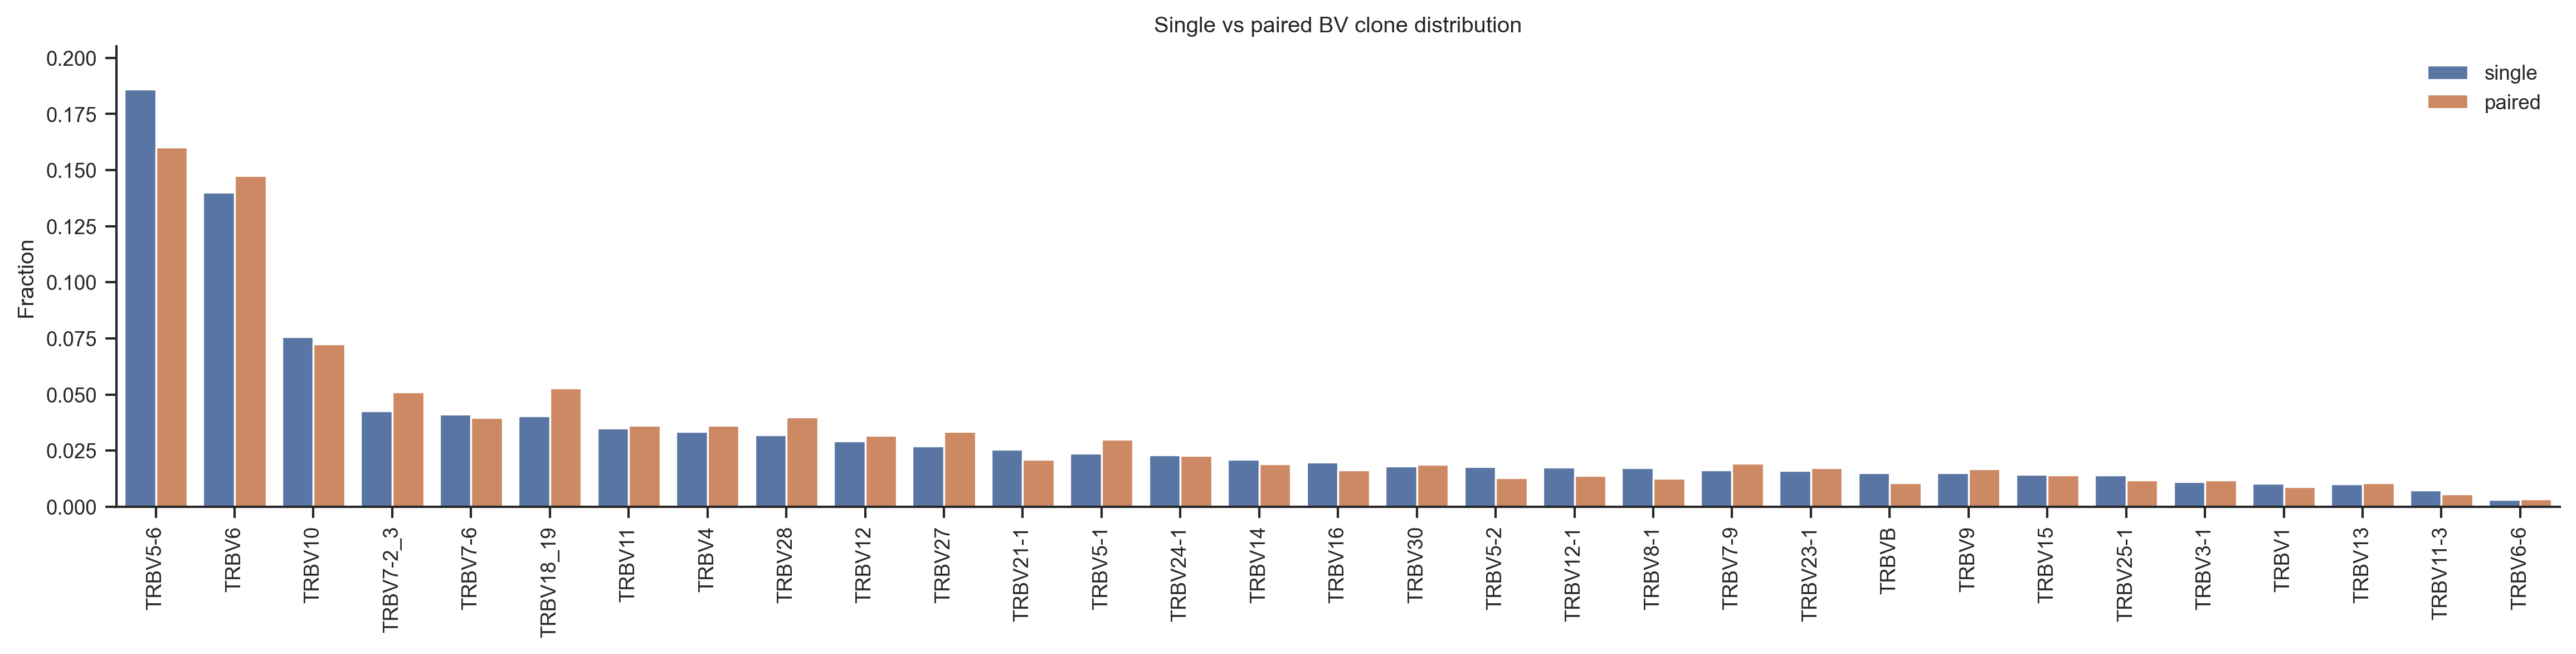

In [15]:
plot_side_by_side_counts(
    bv_counts,
    normalize=True,
    title="Single vs paired BV clone distribution",
    annotate_per_category=False,
)